# Machine Learning Capstone - Review 1
## Corporate Credit Rating with Financial Ratios

**Tracks covered:** Regression and Classification Part A

**Goal:** Predict a credit rating score using financial ratios and classify companies into the given binary rating classes.

## 1. Problem Statement

Credit ratings describe the financial risk of a company. This project uses financial ratios to build machine learning models that can estimate the credit rating.

- **Regression:** Predict the ordered credit rating score.
- **Classification:** Predict the given binary rating class.

The models are compared using common test data so that their performance can be compared fairly.

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

## 3. Load the Dataset

In [2]:
df = pd.read_csv('corporateCreditRatingWithFinancialRatios.csv')

print("Shape:", df.shape)
df.head()

Shape: (7805, 25)


,Rating Agency,Corporation,Rating,Rating Date,CIK,Binary Rating,SIC Code,Sector,Ticker,Current Ratio,Long-term Debt / Capital,Debt/Equity Ratio,Gross Margin,Operating Margin,EBIT Margin,EBITDA Margin,Pre-Tax Profit Margin,Net Profit Margin,Asset Turnover,ROE - Return On Equity,Return On Tangible Equity,ROA - Return On Assets,ROI - Return On Investment,Operating Cash Flow Per Share,Free Cash Flow Per Share
0,Standard & Poor's Ratings Services,American States Water Co.,A-,2010-07-30,1056903,1,4941.0,Utils,AWR,1.1507,0.4551,0.8847,77.6230,19.4839,19.4839,28.9834,13.6093,8.3224,0.3173,8.1724,8.1978,2.6385,4.4530,1.9957,-0.1333
1,Standard & Poor's Ratings Services,Automatic Data Processing Inc.,AAA,2010-09-16,8670,1,7374.0,BusEq,ADP,1.1129,0.0072,0.0073,43.6619,19.8327,19.8327,23.9379,20.8699,13.5690,0.3324,22.0354,47.2858,4.4944,21.8765,0.2501,0.3132
2,Standard & Poor's Ratings Services,Avnet Inc.,BBB-,2010-11-23,8858,1,5065.0,Shops,AVT,1.9276,0.2924,0.4255,11.9008,3.3173,3.3173,3.6338,3.0536,2.1418,2.4620,13.6376,16.7991,5.2731,9.6494,-7.6079,-7.3231
3,Standard & Poor's Ratings Services,California Water Service Co.,AA-,2010-06-29,1035201,1,4941.0,Utils,CWT,0.8358,0.4708,0.9491,64.5096,18.4549,18.4549,27.9377,15.1135,9.0246,0.2946,9.6412,9.7015,2.6583,5.1018,1.7438,-0.8999
4,Standard & Poor's Ratings Services,Cardinal Health Inc.,A,2010-07-14,721371,1,5122.0,Shops,CAH,1.2931,0.2644,0.4036,3.8385,1.3269,1.3269,1.5847,1.2304,0.6518,4.9276,11.1256,19.4184,2.9364,8.1844,1.9725,2.4174


## 4. Dataset Audit

In [3]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Data Types:
Rating Agency                     object
Corporation                       object
Rating                            object
Rating Date                       object
CIK                                int64
Binary Rating                      int64
SIC Code                         float64
Sector                            object
Ticker                            object
Current Ratio                    float64
Long-term Debt / Capital         float64
Debt/Equity Ratio                float64
Gross Margin                     float64
Operating Margin                 float64
EBIT Margin                      float64
EBITDA Margin                    float64
Pre-Tax Profit Margin            float64
Net Profit Margin                float64
Asset Turnover                   float64
ROE - Return On Equity           float64
Return On Tangible Equity        float64
ROA - Return On Assets           float64
ROI - Return On Investment       float64
Operating Cash Flow Per Share    float64
Free

### Observation

The dataset contains **7,805 rows and 25 columns**. There are no missing values and no duplicate rows, so no row needs to be removed for these two reasons.

## 5. Target Distribution

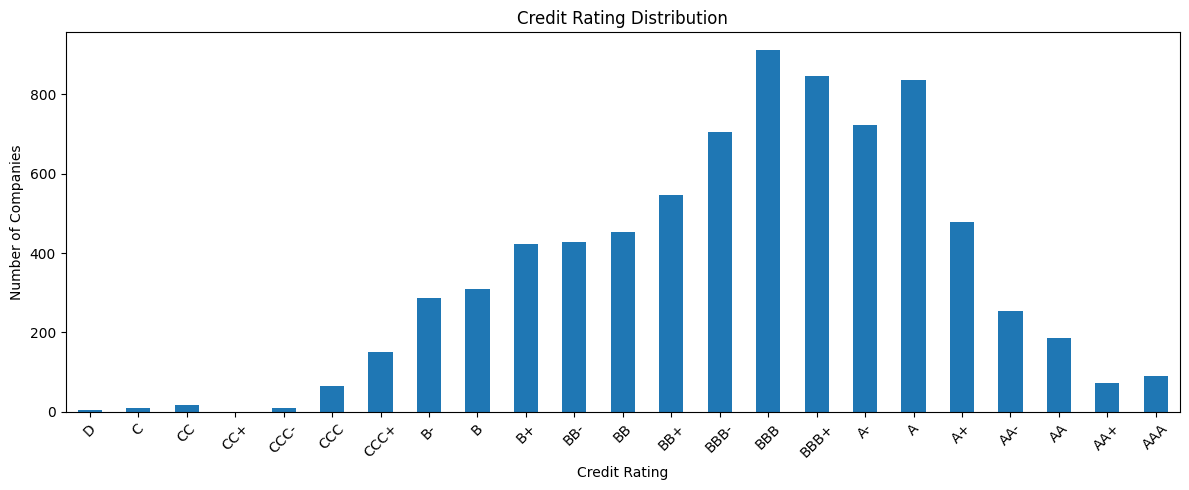

Binary Rating Distribution:
Binary Rating
1    5099
0    2706
Name: count, dtype: int64


In [4]:
rating_order = [
    'D', 'C', 'CC', 'CC+', 'CCC-', 'CCC', 'CCC+',
    'B-', 'B', 'B+', 'BB-', 'BB', 'BB+',
    'BBB-', 'BBB', 'BBB+', 'A-', 'A', 'A+',
    'AA-', 'AA', 'AA+', 'AAA'
]

rating_counts = df['Rating'].value_counts().reindex(rating_order, fill_value=0)

plt.figure(figsize=(12, 5))
rating_counts.plot(kind='bar')
plt.title('Credit Rating Distribution')
plt.xlabel('Credit Rating')
plt.ylabel('Number of Companies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Binary Rating Distribution:")
print(df['Binary Rating'].value_counts())

### Observation

The rating classes are not equally distributed. Some ratings have many more observations than others. The binary target is also somewhat imbalanced, so stratified splitting is used for classification.

## 6. Feature Distribution

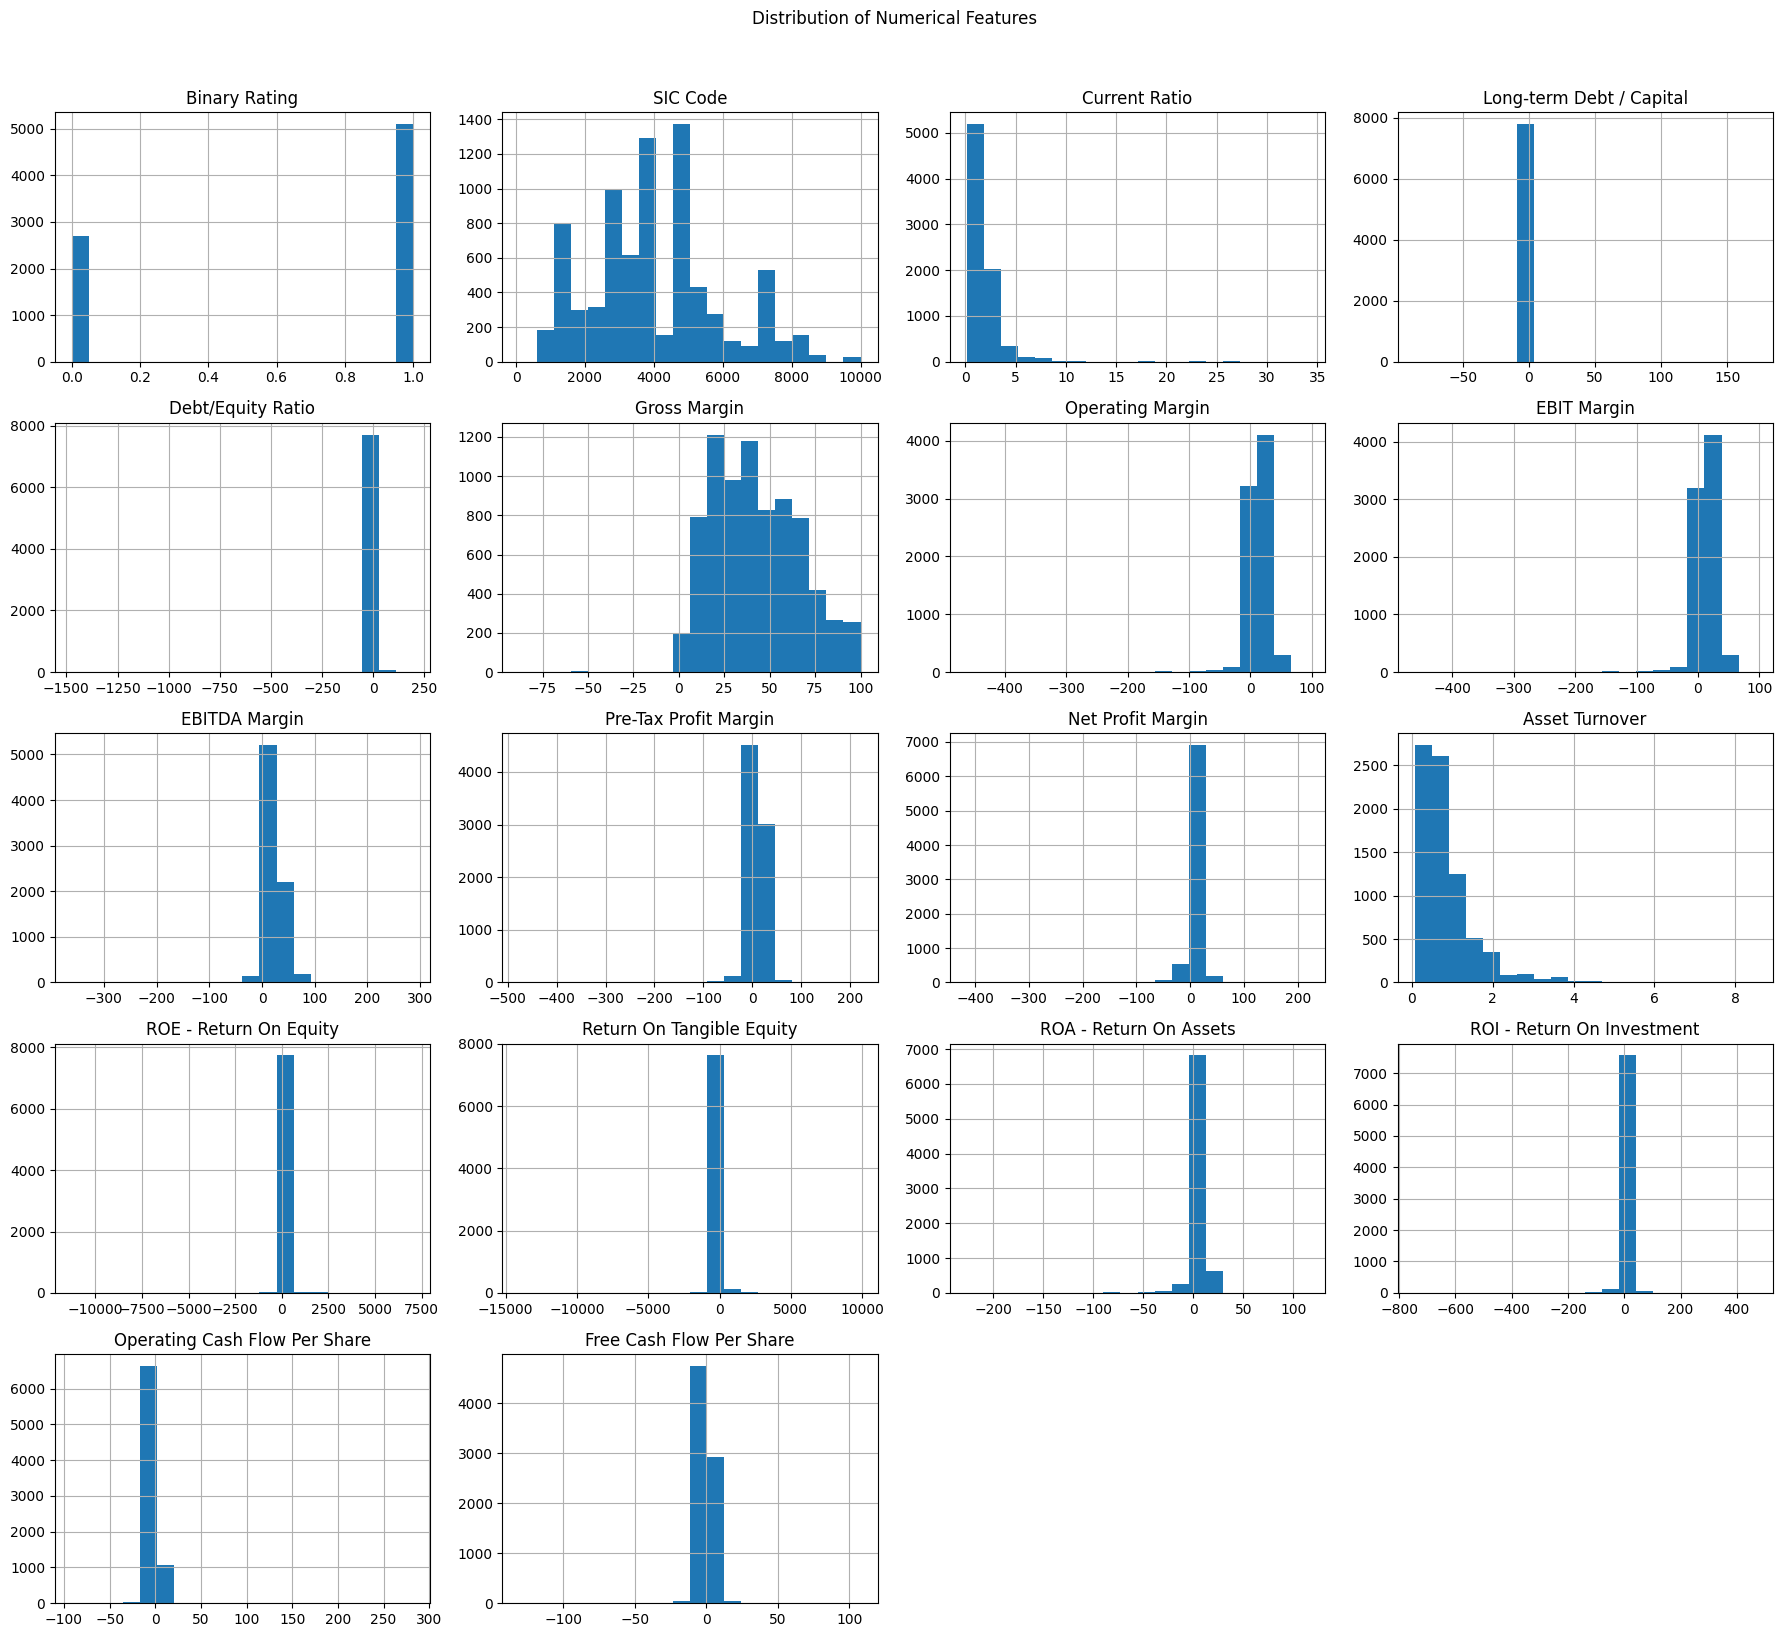

In [5]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('CIK')

df[num_cols].hist(figsize=(18, 16), bins=20)
plt.suptitle('Distribution of Numerical Features', y=1.02)
plt.tight_layout()
plt.show()

### Observation

The financial ratios have different ranges and several features are skewed. This supports the use of scaling for distance-based and linear models.

## 7. Sector Distribution

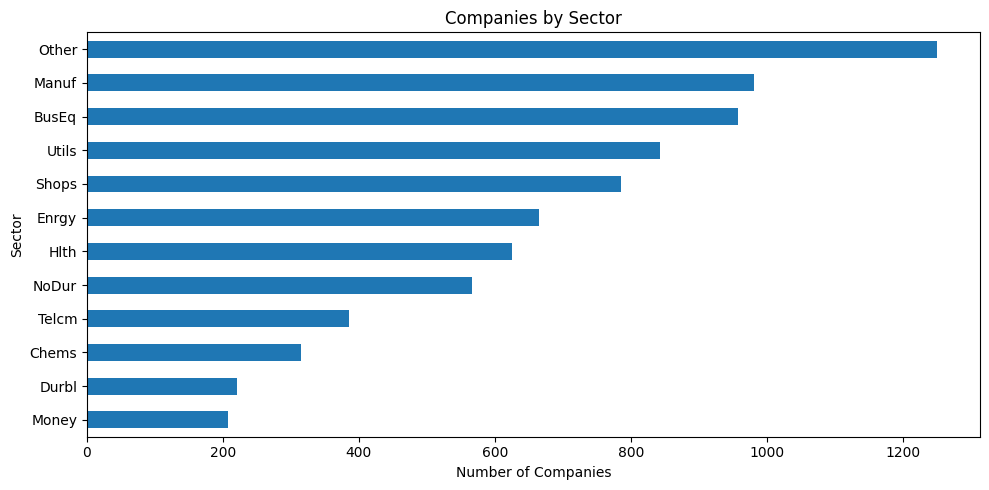

In [6]:
sector_counts = df['Sector'].value_counts()

plt.figure(figsize=(10, 5))
sector_counts.sort_values().plot(kind='barh')
plt.title('Companies by Sector')
plt.xlabel('Number of Companies')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

### Observation

The dataset contains companies from different sectors. Sector is categorical, so it is converted into dummy variables before model training.

## 8. Correlation Heatmap

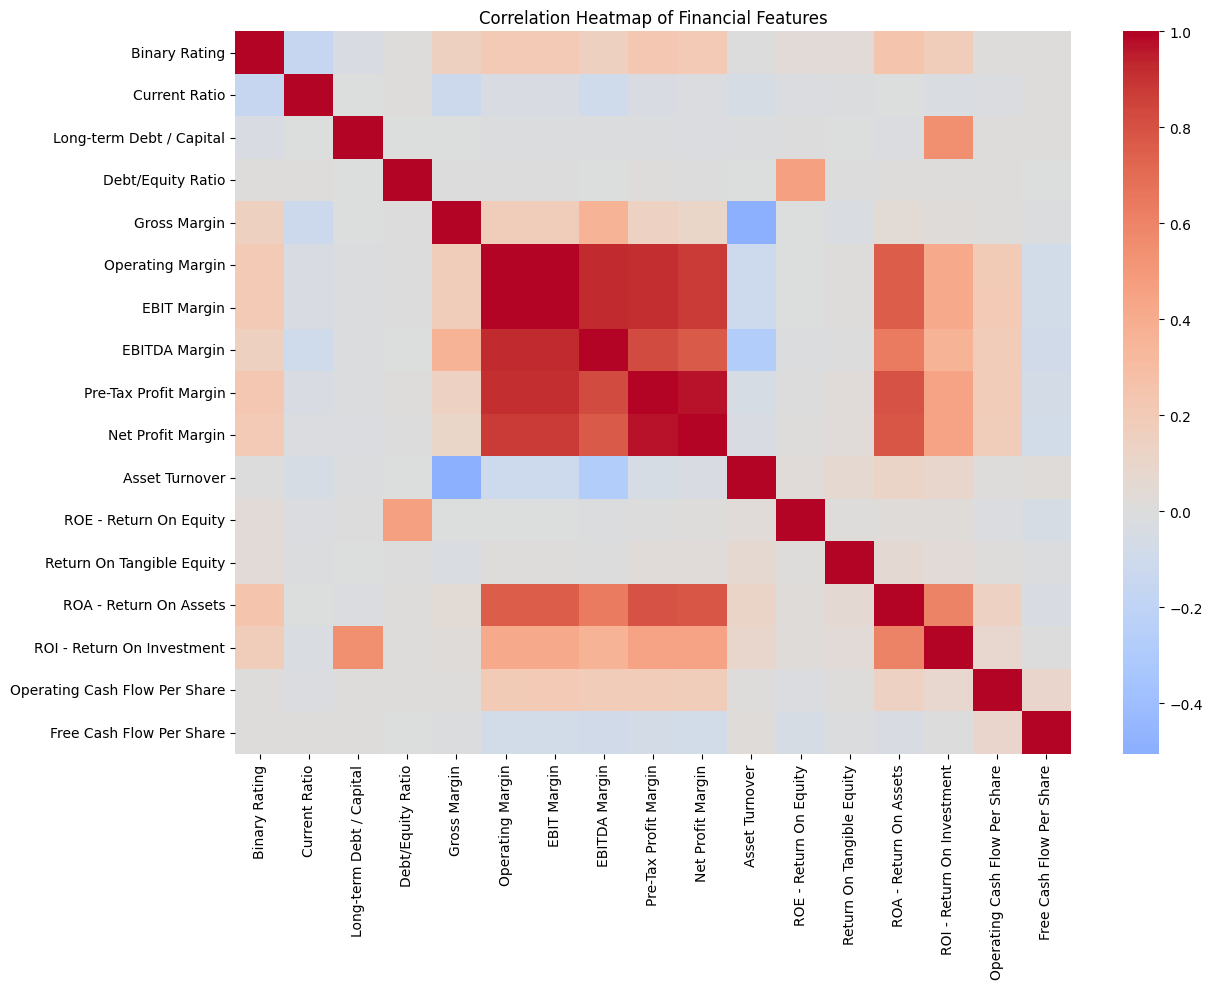

In [7]:
corr_cols = [
    'Binary Rating',
    'Current Ratio',
    'Long-term Debt / Capital',
    'Debt/Equity Ratio',
    'Gross Margin',
    'Operating Margin',
    'EBIT Margin',
    'EBITDA Margin',
    'Pre-Tax Profit Margin',
    'Net Profit Margin',
    'Asset Turnover',
    'ROE - Return On Equity',
    'Return On Tangible Equity',
    'ROA - Return On Assets',
    'ROI - Return On Investment',
    'Operating Cash Flow Per Share',
    'Free Cash Flow Per Share'
]

plt.figure(figsize=(13, 10))
sns.heatmap(df[corr_cols].corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Financial Features')
plt.tight_layout()
plt.show()

### Observation

The heatmap shows relationships among the financial ratios. Profitability measures such as ROA and profit margins have useful relationships with the credit rating, so they are retained for modelling.

## 9. Feature vs Rating Scatter Plots

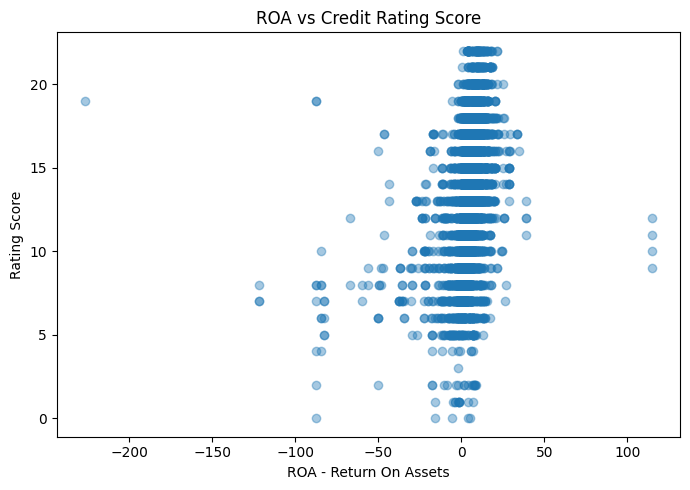

In [8]:
rating_map = {
    'AAA': 22, 'AA+': 21, 'AA': 20, 'AA-': 19,
    'A+': 18, 'A': 17, 'A-': 16,
    'BBB+': 15, 'BBB': 14, 'BBB-': 13,
    'BB+': 12, 'BB': 11, 'BB-': 10,
    'B+': 9, 'B': 8, 'B-': 7,
    'CCC+': 6, 'CCC': 5, 'CCC-': 4,
    'CC+': 3, 'CC': 2, 'C': 1, 'D': 0
}

df['Rating_Score'] = df['Rating'].map(rating_map)

plt.figure(figsize=(7, 5))
plt.scatter(df['ROA - Return On Assets'], df['Rating_Score'], alpha=0.4)
plt.title('ROA vs Credit Rating Score')
plt.xlabel('ROA - Return On Assets')
plt.ylabel('Rating Score')
plt.tight_layout()
plt.show()

### Observation

Companies with higher ROA generally tend to have higher rating scores. This suggests that profitability is useful for credit rating prediction.

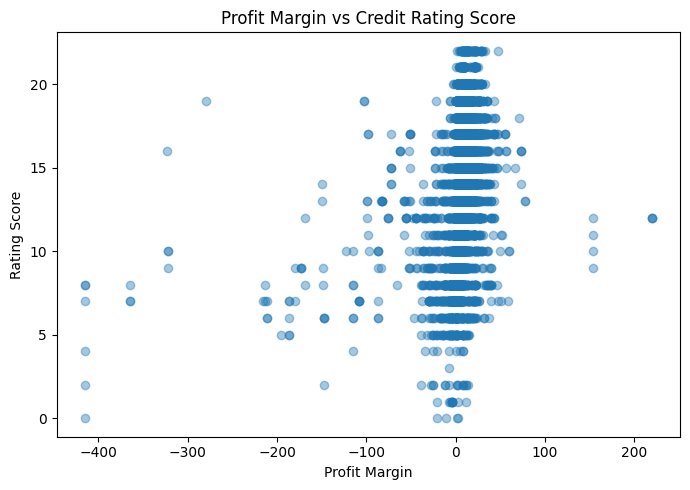

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Average Profit Margin'] if 'Average Profit Margin' in df.columns else df['Net Profit Margin'],
            df['Rating_Score'], alpha=0.4)
plt.title('Profit Margin vs Credit Rating Score')
plt.xlabel('Profit Margin')
plt.ylabel('Rating Score')
plt.tight_layout()
plt.show()

### Observation

Profitability also shows a positive relationship with rating score. This supports using profit-margin information in the regression models.

## 10. Feature Engineering

In [10]:
# Average of the main profit margin measures
profit_cols = [
    'Gross Margin',
    'Operating Margin',
    'EBIT Margin',
    'EBITDA Margin',
    'Pre-Tax Profit Margin',
    'Net Profit Margin'
]

df['Average Profit Margin'] = df[profit_cols].mean(axis=1)

print(df[['Average Profit Margin']].head())

   Average Profit Margin
0              27.917650
1              23.617350
2               4.560767
3              25.582533
4               1.659867


### Why this feature?

The six margin features measure different levels of profitability. Their average gives one overall profitability measure and may help the models capture the company's general profit strength.

## 10.1 Outlier Check

In [11]:
# Count IQR outliers in numerical model features
check_cols = [
    c for c in df.select_dtypes(include=np.number).columns
    if c not in ['CIK', 'Binary Rating', 'Rating_Score']
]

outlier_counts = {}

for col in check_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_table = pd.Series(outlier_counts, name='Outlier Count')
outlier_table.sort_values(ascending=False).head(10)

Return On Tangible Equity        1177
Debt/Equity Ratio                 990
ROE - Return On Equity            981
Free Cash Flow Per Share          955
Operating Cash Flow Per Share     896
Net Profit Margin                 625
Pre-Tax Profit Margin             599
ROI - Return On Investment        594
ROA - Return On Assets            544
Current Ratio                     506
Name: Outlier Count, dtype: int64


### Observation

Several financial ratio features contain extreme values. These values are not removed as rows; instead, they are clipped using IQR limits calculated from the training data.


## 11. Prepare the Data

In [12]:
# Columns that identify the company or rating record
drop_cols = [
    'Rating Agency',
    'Corporation',
    'Rating',
    'Rating Date',
    'CIK',
    'Ticker'
]

model_df = df.drop(columns=drop_cols)

X = model_df.drop(columns=['Rating_Score', 'Binary Rating'])
y_reg = model_df['Rating_Score']
y_clf = model_df['Binary Rating']

print("Features before encoding:", X.shape[1])

Features before encoding: 19


## 12. Train-Test Split

In [13]:
# Same 80:20 split for regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Stratified split for classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Regression training rows:", X_train_r.shape[0])
print("Regression test rows:", X_test_r.shape[0])
print("Classification training rows:", X_train_c.shape[0])
print("Classification test rows:", X_test_c.shape[0])

Regression training rows: 6244
Regression test rows: 1561
Classification training rows: 6244
Classification test rows: 1561


## 13. Encode and Treat Outliers

In [14]:
def clip_outliers(train, test):
    train = train.copy()
    test = test.copy()

    for col in train.columns:
        q1 = train[col].quantile(0.25)
        q3 = train[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        train[col] = train[col].clip(lower, upper)
        test[col] = test[col].clip(lower, upper)

    return train, test

# Convert Sector into dummy variables.
X_train_r = pd.get_dummies(X_train_r, columns=['Sector'], drop_first=True, dtype=int)
X_test_r = pd.get_dummies(X_test_r, columns=['Sector'], drop_first=True, dtype=int)

X_train_r, X_test_r = X_train_r.align(
    X_test_r, join='left', axis=1, fill_value=0
)

X_train_c = pd.get_dummies(X_train_c, columns=['Sector'], drop_first=True, dtype=int)
X_test_c = pd.get_dummies(X_test_c, columns=['Sector'], drop_first=True, dtype=int)

X_train_c, X_test_c = X_train_c.align(
    X_test_c, join='left', axis=1, fill_value=0
)

# Clip extreme values using only training-set limits.
X_train_r, X_test_r = clip_outliers(X_train_r, X_test_r)
X_train_c, X_test_c = clip_outliers(X_train_c, X_test_c)

print("Final regression features:", X_train_r.shape[1])

Final regression features: 29


### Observation

There were no missing values or duplicate rows. Extreme numerical values are clipped using IQR limits calculated from the training data. Sector is one-hot encoded so that it is not treated as an ordered number.

## 14. Feature Scaling

In [15]:
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print("Scaling completed.")

Scaling completed.


### Why scaling?

Scaling puts the features on a similar range. It is especially important for Ridge, Lasso, ElasticNet, SVR and KNN.